# Simulated WCC H-alpha images of PDS 70: raw, radial-profile, RDI and roll ADI

**Purpose.** Show what the numbers in `halpha_hci_feasibility.ipynb` and `halpha_hci_jitter_strehl.ipynb`
look like as images: a 1 h stack of the PDS 70 host in the 2 nm H-alpha filter with planets b and c injected,
before and after three levels of PSF subtraction. Same instrument model (`wcc_etc` via `wcc_sim`), same
pupil-plane PSF (`hci_psf.WfePSF`), and the simulator's own noise stage
(`wcc_sim.render.add_noise_and_digitize`: sky + dark, Poisson, per-frame read noise, saturation, 16-bit ADU).

**Set-up.** 81 x 81 IMX455 pixels (1.37" square, 16.87 mas/px). Host K7V, G = 11.6; planets b
($8.1\times10^{-16}$ erg s$^{-1}$ cm$^{-2}$, 160 mas, PA 150°) and c ($3.1\times10^{-16}$, 210 mas, PA 280°).
Frames fill the peak pixel to half the well (7.6-12 s depending on the PSF); the science stack is 1 h, the
reference stack another 1 h on the same star (a stand-in for a reference star of the same brightness).
Between the science and the reference sequences, and between the two halves of the roll pair, the wavefront
drifts by 2.8 nm RMS with the same power-law spectrum as the static error (the memo's reference case).

**Rows.** (S = 1, 10 mas jitter), (S = 0.82, 10 mas), (S = 0.82, 20 mas), with S at 656 nm and 0.82 the
requirement ($S = 0.8$ at r).

**Columns.** Raw stack; raw minus its own azimuthal mean (radial-profile subtraction); reference-star
differential imaging (RDI: science minus reference stack, then minus the azimuthal mean of the difference);
roll-angle differential imaging (ADI: two 30 min halves at roll 0° and 30°, star-aligned, differenced and
derotated, which removes any symmetric residual by construction) with the 2.8 nm drift between the halves;
and the same ADI with no drift between the halves (the photon-limited ideal). Planet positions are circled;
the inner 60 mas is masked in the residual panels. The last figure gives the residual noise per 2 px aperture
versus separation for each method, with the planets' injected signal, so the SNR of each image is visible.

In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm, TwoSlopeNorm
from scipy.ndimage import rotate as nd_rotate
from astropy.table import Table

plt.style.use('gks')
warnings.filterwarnings('ignore')

from hci_psf import Instrument, WfePSF, azimuthal_mean_image, strehl_at, OVERSAMPLE, STAMP_NPIX
from wcc_sim.render import render_scene, add_noise_and_digitize, bin_oversampled

TEAL, RED, AMBER, BLUE, GREEN, DBLUE = '#00798c', '#d1495b', '#edae49', '#30638e', '#66a182', '#003d5b'
OUT = 'halpha_hci_out'; os.makedirs(OUT, exist_ok=True)
def savefig(fig, name):
    fig.savefig(os.path.join(OUT, name + '.png'), dpi=200); fig.savefig(os.path.join(OUT, name + '.pdf'))

SF = 'zwo:halpha2'
inst = Instrument(SF, 'K7V', 11.6)
S_REQ = float(strehl_at(0.8, 656.3))
PLANETS = {'b': dict(sep_mas=160.0, pa_deg=150.0, flux=8.1e-16), 'c': dict(sep_mas=210.0, pa_deg=280.0, flux=3.1e-16)}
CASES = [('S = 1, 10 mas', 1.0, 10.0), (f'S = {S_REQ:.2f}, 10 mas', S_REQ, 10.0), (f'S = {S_REQ:.2f}, 20 mas', S_REQ, 20.0)]
T_SCI, T_REF = 3600.0, 3600.0
DRIFT_NM = 2.8
ROLL_DEG = 30.0
R_AP = 2.0
N = STAMP_NPIX; C = (N - 1) / 2.0
PLATE = inst.plate_mas
rng = np.random.default_rng(7)

def planet_xy(sep_mas, pa_deg, roll_deg=0.0):
    # PA east of north with north up, east left: x = -sin(PA), y = +cos(PA)
    pa = np.deg2rad(pa_deg + roll_deg); r = sep_mas / PLATE
    return C - r * np.sin(pa), C + r * np.cos(pa)

print(f'star {inst.star_rate:.4g} e-/s; planets:', {k: f"{inst.line_rate(p['flux']):.2f} e-/s" for k, p in PLANETS.items()},
      f'; well {inst.well_depth:.0f} e-, read noise {inst.read_noise:.1f} e-')

star 1.231e+04 e-/s; planets: {'b': '7.05 e-/s', 'c': '2.70 e-/s'} ; well 16275 e-, read noise 3.0 e-


## 1. Build the stacks

`add_noise_and_digitize` with `n_reads = N_frames` reproduces the statistics of an N-frame stack (Poisson on the
total, read noise $\times\sqrt{N}$, saturation checked per frame), which is what the ETC does too.

In [2]:
def stack(psf_fine, t_total, with_planets=True, roll_deg=0.0, jitter_note=''):
    # star at the centre, planets at (sep, PA + roll); frames = t_total / t_frame at half well
    peak = float(bin_oversampled(psf_fine, OVERSAMPLE).max())
    t_frame = 0.5 * inst.well_depth / (inst.star_rate * peak)
    n_frames = max(int(np.ceil(t_total / t_frame)), 1)
    xs, ys, fl = [C], [C], [inst.star_rate * t_total]
    if with_planets:
        for p in PLANETS.values():
            x, y = planet_xy(p['sep_mas'], p['pa_deg'], roll_deg)
            xs.append(x); ys.append(y); fl.append(inst.line_rate(p['flux']) * t_total)
    clean = render_scene((N, N), xs, ys, fl, psf_fine, OVERSAMPLE)
    out = add_noise_and_digitize(clean, inst.sim, t_total, n_frames, rng, add_noise=True)
    assert not out['satmask'].any(), 'saturated pixel in the stack'
    return dict(image=out['image_e'].astype(float), clean=clean.astype(float), t_frame=t_frame, n_frames=n_frames)

def planet_only(psf_fine, t_total, roll_deg=0.0):
    xs, ys, fl = [], [], []
    for p in PLANETS.values():
        x, y = planet_xy(p['sep_mas'], p['pa_deg'], roll_deg); xs.append(x); ys.append(y); fl.append(inst.line_rate(p['flux']) * t_total)
    return render_scene((N, N), xs, ys, fl, psf_fine, OVERSAMPLE).astype(float)

def rotate_about_centre(img, deg):
    return nd_rotate(img, deg, reshape=False, order=1, mode='constant', cval=0.0)

t0 = time.time()
RES = []
for label, S, jit in CASES:
    w = WfePSF(inst, seed=11)
    stat = np.zeros((w.n_pup, w.n_pup)) if S >= 1 else w.screen_for_strehl(S)
    drift_ref = w.psd_screen(2.5, 1.0, None, DRIFT_NM)
    drift_roll = w.psd_screen(2.5, 1.0, None, DRIFT_NM)
    psf_sci = w.psf(stat, jit)
    psf_ref = w.psf(stat + drift_ref, jit)
    psf_rollB = w.psf(stat + drift_roll, jit)
    sci = stack(psf_sci, T_SCI)
    ref = stack(psf_ref, T_REF, with_planets=False)
    half_a = stack(psf_sci, T_SCI / 2)
    half_b = stack(psf_rollB, T_SCI / 2, roll_deg=ROLL_DEG)
    half_b0 = stack(psf_sci, T_SCI / 2, roll_deg=ROLL_DEG)        # no drift between the halves
    # choose the derotation sign on a noiseless planet-only pair
    pa_clean, pb_clean = planet_only(psf_sci, T_SCI / 2), planet_only(psf_rollB, T_SCI / 2, ROLL_DEG)
    Dc = pa_clean - pb_clean
    xb, yb = planet_xy(**{k: PLANETS['b'][k] for k in ('sep_mas', 'pa_deg')})
    yy, xx = np.mgrid[:N, :N]; ap_b = np.hypot(xx - xb, yy - yb) <= R_AP
    sgn = max((+1, -1), key=lambda s: (Dc - rotate_about_centre(Dc, s * ROLL_DEG))[ap_b].sum())
    def adi_of(hb):
        D = half_a['image'] - hb['image']
        return 0.5 * (D - rotate_about_centre(D, sgn * ROLL_DEG))  # /2: planet counted twice
    rdi = sci['image'] - ref['image'] * (T_SCI / T_REF)
    RES.append(dict(label=label, S=S, jitter=jit, raw=sci['image'], radial=sci['image'] - azimuthal_mean_image(sci['image']),
                    rdi=rdi - azimuthal_mean_image(rdi), adi=adi_of(half_b), adi0=adi_of(half_b0),
                    clean_planets=planet_only(psf_sci, T_SCI), t_frame=sci['t_frame'], n_frames=sci['n_frames'], adi_sign=sgn))
    print(f"{label}: frame {sci['t_frame']:.1f} s x {sci['n_frames']} frames; peak pixel {sci['image'].max():.3g} e- in the stack; "
          f"ADI derotation sign {sgn:+d}")
print(f'stacks in {time.time() - t0:.0f} s')

S = 1, 10 mas: frame 7.6 s x 476 frames; peak pixel 3.87e+06 e- in the stack; ADI derotation sign +1


S = 0.82, 10 mas: frame 9.0 s x 401 frames; peak pixel 3.26e+06 e- in the stack; ADI derotation sign +1


S = 0.82, 20 mas: frame 14.8 s x 245 frames; peak pixel 1.98e+06 e- in the stack; ADI derotation sign +1
stacks in 7 s


## 2. The images

Log (asinh) stretch for the raw stack; symmetric linear stretch for the residual images at $\pm 4\times$ the RMS
of the residual in the 100-400 mas annulus of the worst row, the same in each column so rows can be compared.
Circles mark the injected planets (b at 160 mas, c at 210 mas); dashed circles in the ADI columns are where
the negative lobes of b fall.

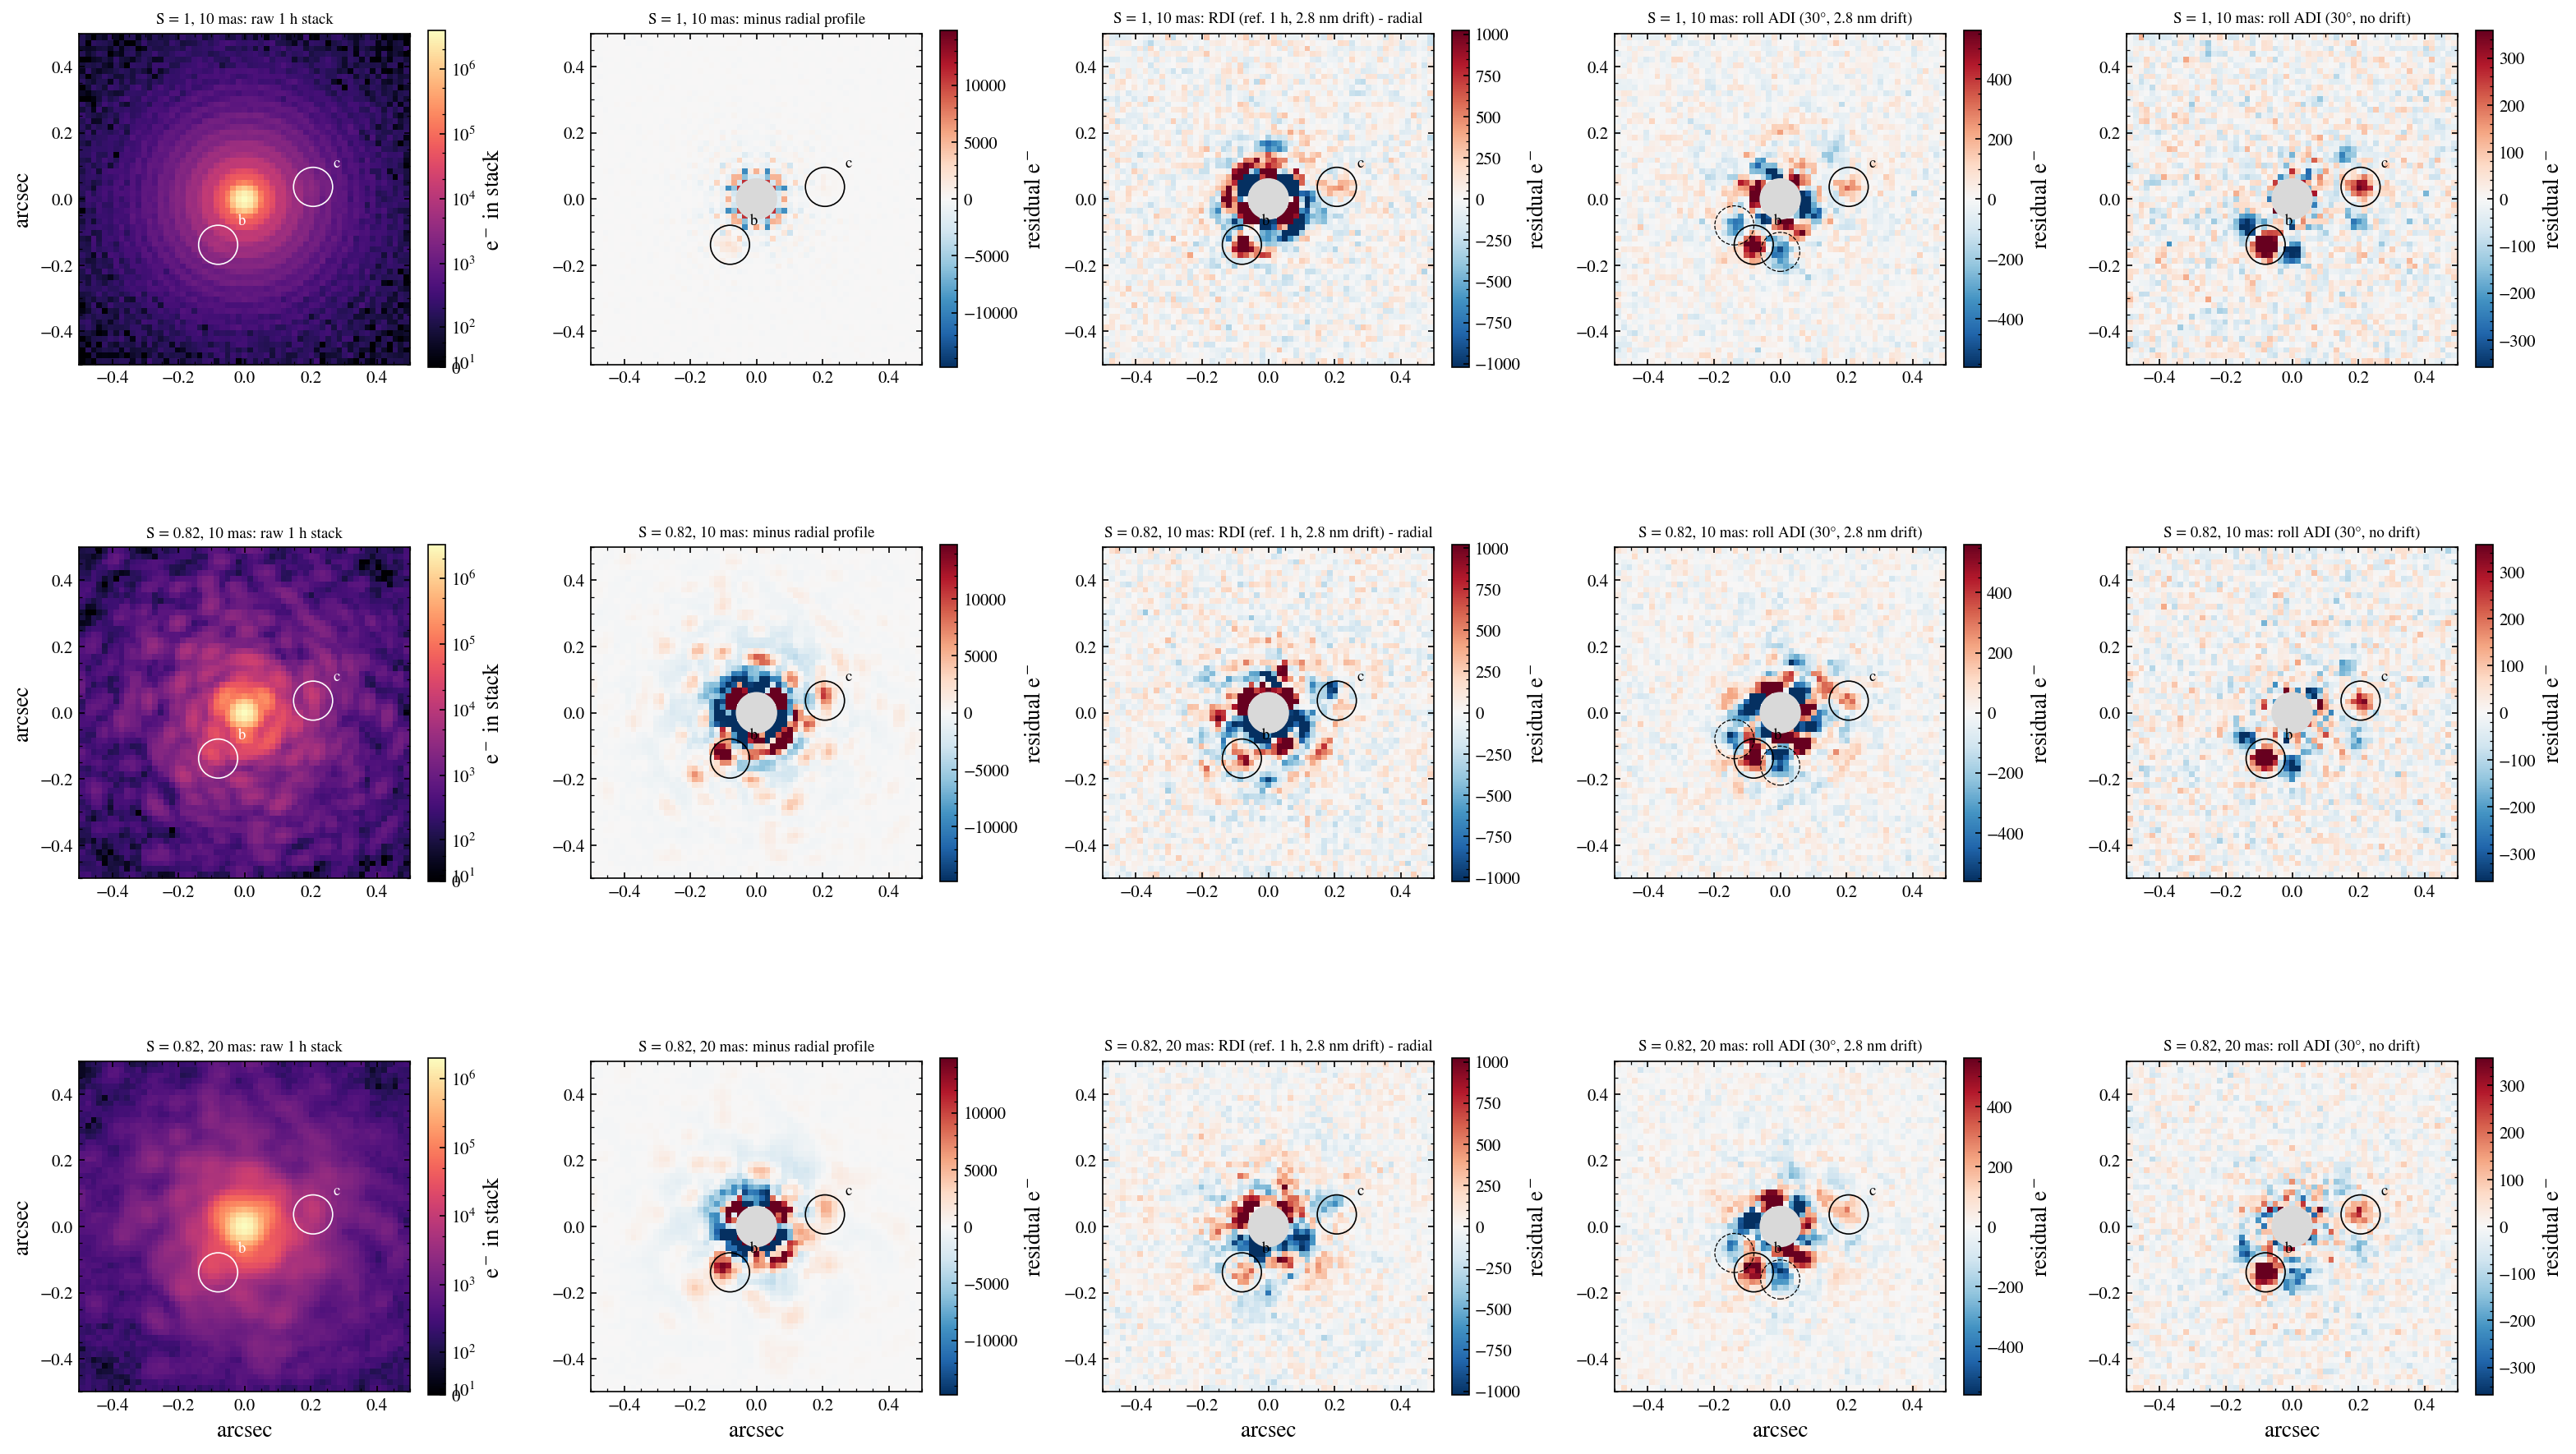

In [3]:
ext = np.array([-1, 1, -1, 1]) * (N / 2) * PLATE / 1000   # arcsec
cols = [('raw', 'raw 1 h stack'), ('radial', 'minus radial profile'), ('rdi', f'RDI (ref. 1 h, {DRIFT_NM} nm drift) - radial'),
        ('adi', f'roll ADI ({ROLL_DEG:.0f}°, {DRIFT_NM} nm drift)'), ('adi0', f'roll ADI ({ROLL_DEG:.0f}°, no drift)')]
yy, xx = np.mgrid[:N, :N]; RR = np.hypot(xx - C, yy - C) * PLATE
CORE = RR < 60.0                                     # mask the core in residual panels (60 mas)
ANN = (RR > 100) & (RR < 400)
# one symmetric colour scale per column: 4 x the rms of the residual in the 100-400 mas annulus, worst row
vmax_res = {c: 4 * max(np.std(r[c][ANN]) for r in RES) for c, _ in cols[1:]}
fig, axes = plt.subplots(len(RES), len(cols), figsize=(4.2 * len(cols), 4.3 * len(RES)))
for i, r in enumerate(RES):
    for j, (c, title) in enumerate(cols):
        ax = axes[i, j]; img = r[c]
        if c == 'raw':
            im = ax.imshow(img, origin='lower', extent=ext, cmap='magma', norm=AsinhNorm(linear_width=50, vmin=0, vmax=img.max()))
        else:
            shown = np.where(CORE, np.nan, img)
            im = ax.imshow(shown, origin='lower', extent=ext, cmap='RdBu_r', vmin=-vmax_res[c], vmax=vmax_res[c])
            ax.add_patch(plt.Circle((0, 0), 0.06, color='0.85'))
        for name, p in PLANETS.items():
            x, y = planet_xy(p['sep_mas'], p['pa_deg'])
            ax.add_patch(plt.Circle(((x - C) * PLATE / 1000, (y - C) * PLATE / 1000), 3.5 * PLATE / 1000, fill=False, ec='w' if c == 'raw' else 'k', lw=0.8))
            ax.text((x - C) * PLATE / 1000 + 0.06, (y - C) * PLATE / 1000 + 0.06, name, color='w' if c == 'raw' else 'k', fontsize=9)
        if c == 'adi':
            for dpa in (+ROLL_DEG, -ROLL_DEG):
                x, y = planet_xy(PLANETS['b']['sep_mas'], PLANETS['b']['pa_deg'], dpa)
                ax.add_patch(plt.Circle(((x - C) * PLATE / 1000, (y - C) * PLATE / 1000), 3.5 * PLATE / 1000, fill=False, ec='k', lw=0.6, ls='--'))
        ax.set_title(f'{r["label"]}: {title}', fontsize=9); ax.grid(False)
        ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.5, 0.5)
        ax.set_xticks([-0.4, -0.2, 0, 0.2, 0.4]); ax.set_yticks([-0.4, -0.2, 0, 0.2, 0.4])
        if i == len(RES) - 1: ax.set_xlabel('arcsec')
        if j == 0: ax.set_ylabel('arcsec')
        plt.colorbar(im, ax=ax, fraction=0.046, label='e$^-$ in stack' if c == 'raw' else 'residual e$^-$')
fig.tight_layout(); savefig(fig, 'fig13_images_grid')

## 3. What the images are worth: SNR per method

Planet signal = sum in a 2 px aperture at the injected position (noisy image) minus the local mean of the
same aperture at other position angles; noise = standard deviation of the aperture sums at the same separation
over 24 position angles, excluding the angles within 3 apertures of either planet (and of the ADI lobes).
This is the standard small-sample contrast estimate and is what a pipeline would report.

In [4]:
yy, xx = np.mgrid[:N, :N]
def aperture_sum(img, x, y, r=R_AP):
    return img[np.hypot(xx - x, yy - y) <= r].sum()

def snr_at(img, sep_mas, pa_deg, exclude_pas, n_ang=24):
    x0, y0 = planet_xy(sep_mas, pa_deg)
    sig = aperture_sum(img, x0, y0)
    r_px = sep_mas / PLATE
    dpa_excl = np.rad2deg(3 * 2 * R_AP / r_px)
    vals = []
    for pa in np.linspace(0, 360, n_ang, endpoint=False):
        if any(abs((pa - e + 180) % 360 - 180) < dpa_excl for e in exclude_pas):
            continue
        x, y = planet_xy(sep_mas, pa); vals.append(aperture_sum(img, x, y))
    vals = np.array(vals)
    return (sig - vals.mean()) / vals.std(ddof=1), vals.std(ddof=1), len(vals)

rows = []
for r in RES:
    for name, p in PLANETS.items():
        excl = [q['pa_deg'] for q in PLANETS.values()]
        inj = aperture_sum(r['clean_planets'], *planet_xy(p['sep_mas'], p['pa_deg']))
        row = dict(case=r['label'], planet=name, injected_e=inj)
        for c, _ in cols:
            ex = excl + ([p['pa_deg'] + ROLL_DEG, p['pa_deg'] - ROLL_DEG] if c.startswith('adi') else [])
            s, nz, nap = snr_at(r[c], p['sep_mas'], p['pa_deg'], ex)
            row[f'snr_{c}'] = s; row[f'noise_{c}'] = nz
        rows.append(row)
SNR = Table(rows)
for c in SNR.colnames[2:]: SNR[c].format = '%.1f'
SNR.write(os.path.join(OUT, 'images_snr.ecsv'), format='ascii.ecsv', overwrite=True)
print('SNR of the injected planets per method (noise = azimuthal scatter of 2 px aperture sums at the same separation):')
SNR.pprint(max_width=220)

SNR of the injected planets per method (noise = azimuthal scatter of 2 px aperture sums at the same separation):
      case       planet injected_e snr_raw noise_raw snr_radial noise_radial snr_rdi noise_rdi snr_adi noise_adi snr_adi0 noise_adi0
---------------- ------ ---------- ------- --------- ---------- ------------ ------- --------- ------- --------- -------- ----------
   S = 1, 10 mas      b    16375.5     4.4    3204.6        8.3       2122.9     7.9    1698.2    50.6     141.2     59.8      128.6
   S = 1, 10 mas      c     6270.0     2.8    2369.4       16.3        339.6     4.0     861.1     5.8     436.9     34.5       93.6
S = 0.82, 10 mas      b    13799.8     4.2   30981.7        4.1      32982.7     4.6    1253.7    32.7     212.6    116.5       55.1
S = 0.82, 10 mas      c     5291.1     4.5   16475.6        5.0      14579.7    -1.2    1437.7     6.2     347.4     11.7      210.4
S = 0.82, 20 mas      b    10273.4     4.3   25180.5        4.3      26613.2     5.1     

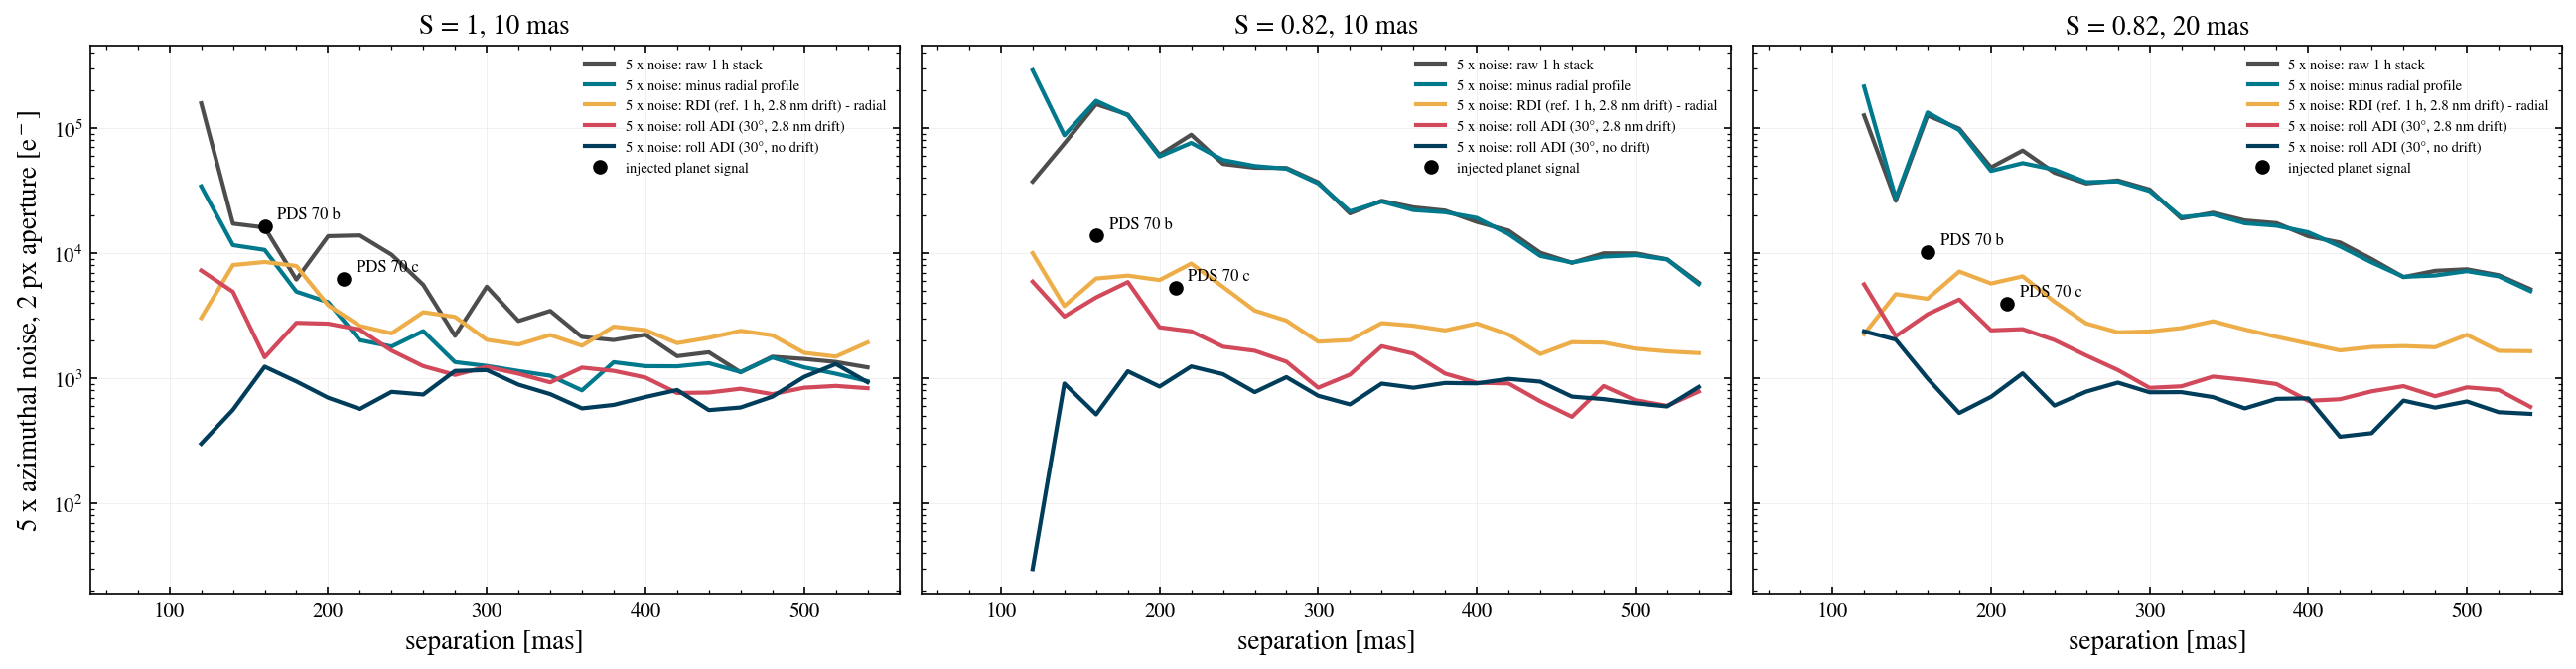

In [5]:
SEPS = np.arange(60.0, 560.0, 20.0)
fig, axes = plt.subplots(1, len(RES), figsize=(5.8 * len(RES), 4.6), sharey=True)
for ax, r in zip(axes, RES):
    for (c, title), col in zip(cols, ['0.3', TEAL, AMBER, RED, DBLUE]):
        noise = []
        for s in SEPS:
            vals = [aperture_sum(r[c], *planet_xy(s, pa)) for pa in np.linspace(0, 360, 24, endpoint=False)
                    if all(abs((pa - q['pa_deg'] + 180) % 360 - 180) > np.rad2deg(3 * 2 * R_AP / (s / PLATE)) for q in PLANETS.values())]
            noise.append(5 * np.std(vals, ddof=1))
        ax.plot(SEPS, noise, color=col, label=f'5 x noise: {title}')
    for name, p in PLANETS.items():
        inj = aperture_sum(r['clean_planets'], *planet_xy(p['sep_mas'], p['pa_deg']))
        ax.plot(p['sep_mas'], inj, 'o', color='k', ms=6); ax.text(p['sep_mas'] + 8, inj * 1.15, f'PDS 70 {name}', fontsize=8)
    ax.set_yscale('log'); ax.set_xlim(50, 560); ax.set_xlabel('separation [mas]'); ax.set_title(r['label'])
    ax.legend(fontsize=7, loc='upper right')
axes[0].set_ylabel('5 x azimuthal noise, 2 px aperture [e$^-$]')
for ax in axes: ax.plot([], [], 'o', color='k', label='injected planet signal'); ax.legend(fontsize=7, loc='upper right')
fig.tight_layout(); savefig(fig, 'fig14_images_noise_vs_sep')

## 4. Reading the images

* **Raw stack.** The planets sit on the Airy rings at $10^{-4}$ of the stellar flux per pixel; b is a visible bump
  on the ring at 160 mas even before any subtraction (its raw ratio is 0.3 of the local stellar light), c is not.
* **Radial-profile subtraction** removes the symmetric wing and leaves the ring residuals from pixelisation
  and the static speckles (rows 2-3). Both planets stand out at S = 1; at S = 0.82 the static speckle pattern
  is comparable to c.
* **RDI** with a reference that has drifted by 2.8 nm leaves the speckle-difference pattern whose amplitude
  the sensitivity notebook quantified: at S = 1 it is set by the drift beating against the Airy rings, at
  S = 0.82 by the drift beating against the static speckles, and c is marginal there. The 20 mas row blurs
  the speckles and the planets alike.
* **Roll ADI** with the same 2.8 nm drift between the halves is limited by the same speckle-difference term
  as RDI; it needs no reference star, and its cost is the negative lobes at $\pm30°$ (and self-subtraction if
  the roll were smaller than the aperture). With no drift between the halves (last column: same thermal
  state) the speckles cancel exactly and both planets are photon-limited detections in every row; that is
  the case to aim for operationally, and it is why the memo asks for wavefront repeatability rather than a
  lower jitter or a higher Strehl.

Caveats as in the other notebooks: single noise realisation, single wavefront realisation per row, ideal
registration and photometric scaling, no near-core scatter, monochromatic unobscured PSF.

## 5. The wavefront spectra behind the speckles

Every speckle floor in this study rests on an assumed wavefront power spectral density (PSD). This section
measures the PSD of the screens that were actually used (azimuthal average of $|\mathcal{F}\{\phi\}|^2$ over the
pupil, normalised so its integral is the wavefront variance), and shows where each one puts its light in the
focal plane. Spatial frequency $f$ in cycles per aperture maps to separation $f\,\lambda/D$ = $f \times 44$ mas,
so PDS 70 b (160 mas) and c (210 mas) sit at 3.6 and 4.8 cycles per aperture.

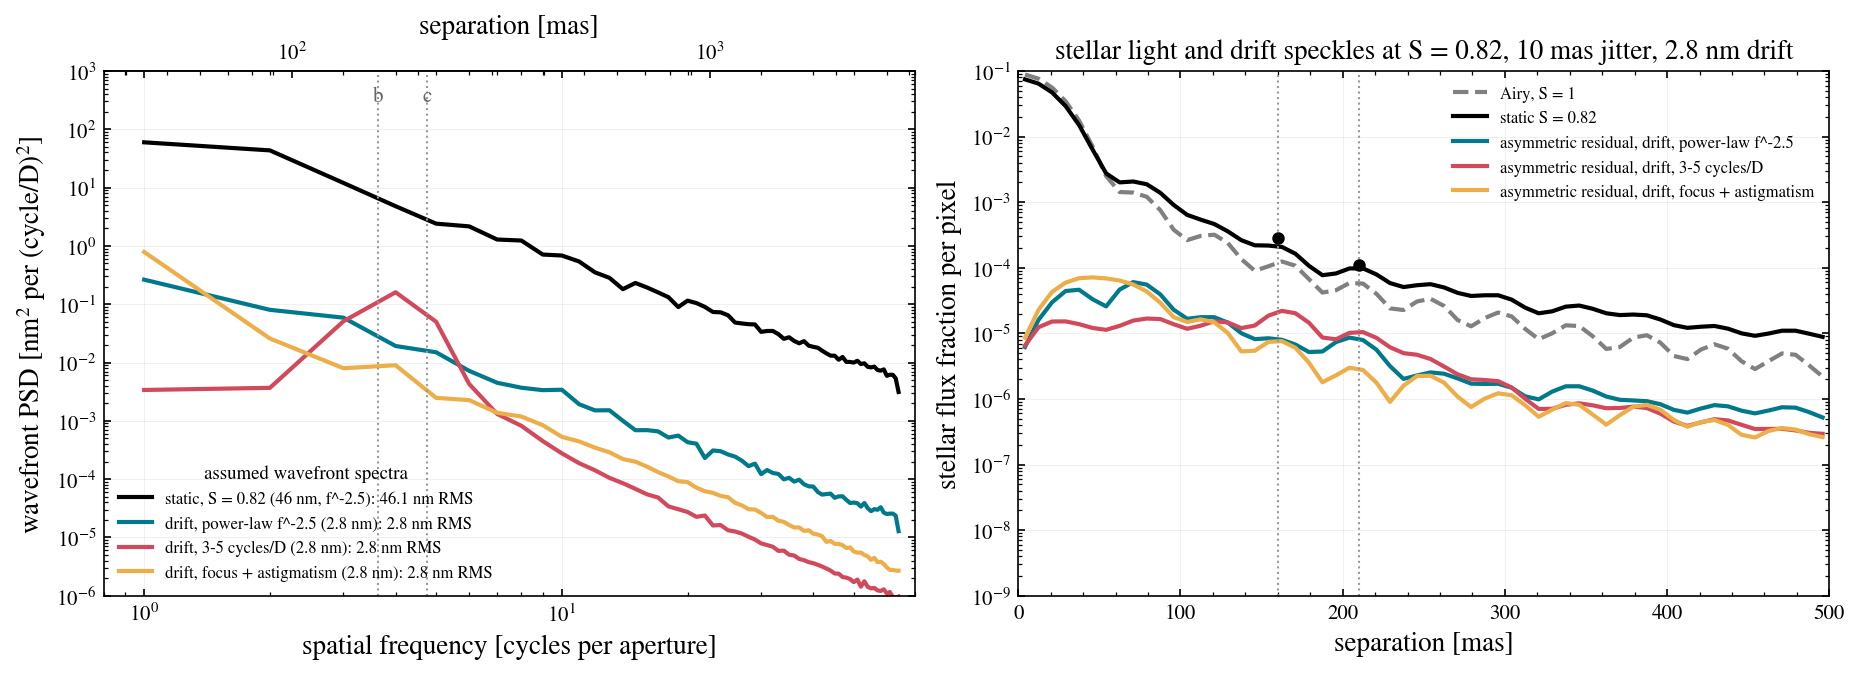

In [6]:
w = WfePSF(inst, seed=11)
LAM_D_MAS = inst.wavelength_m / inst.diameter_m * 206264.806e3
S_STAT = w.screen_for_strehl(S_REQ)
a_lo = DRIFT_NM / np.sqrt(2)
SCREENS = [('static, S = 0.82 (46 nm, f^-2.5)', S_STAT, 'k'),
           (f'drift, power-law f^-2.5 ({DRIFT_NM} nm)', w.psd_screen(2.5, 1.0, None, DRIFT_NM), TEAL),
           (f'drift, 3-5 cycles/D ({DRIFT_NM} nm)', w.psd_screen(0.0, 3.0, 5.0, DRIFT_NM), RED),
           (f'drift, focus + astigmatism ({DRIFT_NM} nm)', w.zernike_screen({'focus': a_lo, 'astig0': a_lo}), AMBER)]

def wfe_psd(screen):
    n = w.n_pup
    P = np.abs(np.fft.fft2(screen)) ** 2 / n ** 4 / w.pupil.mean()   # sum(P) = variance over the pupil [nm^2]
    fx = np.fft.fftfreq(n) * n
    f = np.hypot(fx[None, :], fx[:, None])
    edges = np.arange(0.5, n / 2 + 1)
    idx = np.digitize(f.ravel(), edges)
    tot = np.bincount(idx, P.ravel(), minlength=len(edges) + 1)[1:len(edges)]
    cnt = np.bincount(idx, minlength=len(edges) + 1)[1:len(edges)]
    return 0.5 * (edges[:-1] + edges[1:]), tot / np.maximum(cnt, 1)   # per (cycle/D)^2 cell

def radial_profile(img, nbin=60):
    n = img.shape[0]; c = (n - 1) / 2
    yy, xx = np.mgrid[:n, :n]; r = np.hypot(xx - c, yy - c) * PLATE / OVERSAMPLE
    edges = np.linspace(0, 500, nbin + 1); idx = np.digitize(r.ravel(), edges)
    tot = np.bincount(idx, img.ravel(), minlength=nbin + 2)[1:nbin + 1]
    cnt = np.bincount(idx, minlength=nbin + 2)[1:nbin + 1]
    return 0.5 * (edges[:-1] + edges[1:]), tot / np.maximum(cnt, 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))
for label, scr, col in SCREENS:
    f, P = wfe_psd(scr)
    ax1.plot(f, P, color=col, label=f'{label}: {w.rms_nm(scr):.1f} nm RMS')
ax1.set(xscale='log', yscale='log', xlabel='spatial frequency [cycles per aperture]',
        ylabel=r'wavefront PSD [nm$^2$ per (cycle/D)$^2$]', xlim=(0.8, 70), ylim=(1e-6, 1e3))
for sep, name in ((160, 'b'), (210, 'c')):
    ax1.axvline(sep / LAM_D_MAS, color='0.6', ls=':', lw=1); ax1.text(sep / LAM_D_MAS, 3e2, name, ha='center', color='0.4')
sec = ax1.secondary_xaxis('top', functions=(lambda f: f * LAM_D_MAS, lambda s: s / LAM_D_MAS))
sec.set_xlabel('separation [mas]')
ax1.legend(fontsize=8, loc='lower left', title='assumed wavefront spectra', title_fontsize=9)

# where the light lands: azimuthal mean of the per-pixel stellar flux fraction, 10 mas jitter, fine grid -> per detector pixel
pix = OVERSAMPLE ** 2
psf0 = w.psf(np.zeros_like(S_STAT), 10.0)
psf_stat = w.psf(S_STAT, 10.0)
r, p0 = radial_profile(psf0); ax2.plot(r, p0 * pix, color='0.5', ls='--', label='Airy, S = 1')
r, ps = radial_profile(psf_stat); ax2.plot(r, ps * pix, color='k', label='static S = 0.82')
for label, scr, col in SCREENS[1:]:
    d = w.psf(S_STAT + scr, 10.0) - psf_stat
    d = d - azimuthal_mean_image(d)
    r, pd = radial_profile(d ** 2)
    ax2.plot(r, np.sqrt(pd) * pix, color=col, label=f'asymmetric residual, {label.split(" (")[0]}')
for sep, name in ((160, 'b'), (210, 'c')):
    ax2.axvline(sep, color='0.6', ls=':', lw=1)
for name, p in PLANETS.items():
    ax2.plot(p['sep_mas'], inst.line_rate(p['flux']) / inst.star_rate * 0.5, 'o', color='k', ms=5)
ax2.set(yscale='log', xlabel='separation [mas]', ylabel='stellar flux fraction per pixel', xlim=(0, 500), ylim=(1e-9, 1e-1))
ax2.set_title(f'stellar light and drift speckles at S = 0.82, 10 mas jitter, {DRIFT_NM} nm drift')
ax2.legend(fontsize=8, loc='upper right')
fig.tight_layout(); savefig(fig, 'fig15_wfe_psd')

Left: the static screen carries most of its variance at 1-3 cycles per aperture (the $f^{-2.5}$ slope) and falls
four orders of magnitude by the pupil Nyquist frequency; the power-law drift is the same shape scaled down by
$(2.8/46)^2$; the mid-frequency drift puts all of its 2.8 nm into 3-5 cycles per aperture, exactly where the planets are;
the low-order drift has no power beyond 2 cycles per aperture. Right: the asymmetric residual of each drift, RMS per
detector pixel, against the static PSF and the ideal Airy pattern; the dots are the planets' peak-pixel flux (half of
the line flux in the brightest pixel). The mid-frequency drift is the most damaging per nanometre because its light
lands at the planets; the low-order drift reaches them only through the static speckles it beats against.